In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV, cross_val_score


import sys
sys.path.insert(0, r"C:\Users\20242732\Desktop\cbl\cbl_predictive_new\4cblw010\src")


In [14]:
df = pd.read_parquet(r"C:\Users\20242732\Desktop\cbl\cbl_predictive_new\4cblw010\src\cbl\data\merged.parquet")


In [15]:
print("Sulfonic acid positive:", df['sulfonic_acid'].sum())
print("Guanidino positive:", df['guanidino'].sum())
print("Total samples:", len(df))

Sulfonic acid positive: 77
Guanidino positive: 3145
Total samples: 191872


In [ ]:
# Keep all sulfonic acid (77) and all guanidino (3145) samples
mask_rare = (df['sulfonic_acid'] == 1) | (df['guanidino'] == 1)
df_rare   = df[mask_rare] # 77 sulfonic + 3145 guanidino (some overlap possible)
df_common = df[~mask_rare].sample(n=10000, random_state=42)

df_knn = pd.concat([df_rare, df_common]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Subset size:         ", len(df_knn))
print("Sulfonic acid:       ", df_knn['sulfonic_acid'].sum())
print("Guanidino:           ", df_knn['guanidino'].sum())

X = np.stack(df_knn["transmittance"].values)
y = df_knn[["carboxylic_acid", "amino", "sulfonic_acid", "guanidino"]].values

# Stratify jointly on sulfonic acid and guanidino to ensure both are
# proportionally represented in train and test
strata = df_knn['sulfonic_acid'].astype(str) + df_knn['guanidino'].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=strata
)

print("\nTrain size:", len(X_train))
print("Test size: ", len(X_test))

Subset size:          13215
Sulfonic acid:        77
Guanidino:            3145

Train size: 10572
Test size:  2643


Take a subset bc otherwise training takes too long

In [24]:
trf = StandardScaler()
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

# Wrap KNN in MultiOutputClassifier so one KNN per functional group
knn = MultiOutputClassifier(KNeighborsClassifier(n_neighbors=20)) #try 20 neighbors first
knn.fit(X_train_trf, y_train)
y_pred = knn.predict(X_test_trf)


print("\nPer class results:")
print(classification_report(
    y_test, y_pred,
    target_names=['carboxylic_acid', 'amino', 'sulfonic_acid', 'guanidino'],
    zero_division=0
))


Per class results:
                 precision    recall  f1-score   support

carboxylic_acid       0.97      0.90      0.93       869
          amino       0.96      0.95      0.95      1570
  sulfonic_acid       1.00      0.20      0.33        15
      guanidino       0.93      0.75      0.83       629

      micro avg       0.96      0.89      0.92      3083
      macro avg       0.96      0.70      0.76      3083
   weighted avg       0.96      0.89      0.92      3083
    samples avg       0.93      0.90      0.91      3083



Trying different k values  

In [19]:
# Trying different k values to see if it improves results
for k in [5, 10, 20, 50]:
    knn = MultiOutputClassifier(KNeighborsClassifier(n_neighbors=k))
    knn.fit(X_train_trf, y_train)
    y_pred = knn.predict(X_test_trf)
    
    print(f"\nk={k}")
    print(classification_report(
        y_test, y_pred,
        target_names=['carboxylic_acid', 'amino', 'sulfonic_acid', 'guanidino'],
        zero_division=0
    ))


k=5
                 precision    recall  f1-score   support

carboxylic_acid       0.98      0.94      0.96       425
          amino       0.97      0.97      0.97       592
  sulfonic_acid       1.00      0.60      0.75        15
      guanidino       0.80      0.40      0.53        20

      micro avg       0.97      0.94      0.96      1052
      macro avg       0.94      0.73      0.80      1052
   weighted avg       0.97      0.94      0.95      1052
    samples avg       0.96      0.94      0.95      1052


k=10
                 precision    recall  f1-score   support

carboxylic_acid       0.99      0.93      0.96       425
          amino       0.97      0.97      0.97       592
  sulfonic_acid       1.00      0.47      0.64        15
      guanidino       1.00      0.15      0.26        20

      micro avg       0.98      0.93      0.95      1052
      macro avg       0.99      0.63      0.71      1052
   weighted avg       0.98      0.93      0.95      1052
    samples avg

trying to find optimal k

In [ ]:
param_grid = {'estimator__n_neighbors': range(1, 51)}  # Tests k=1 to 50

knn = MultiOutputClassifier(KNeighborsClassifier())

grid_search = GridSearchCV(
    knn,
    param_grid,
    cv=5,                    # 5-fold cross-validation
    scoring='f1_weighted',   # Good for imbalanced multi-label data
    n_jobs=-1                # Use all CPU cores
)

grid_search.fit(X_train_trf, y_train)

best_k = grid_search.best_params_['estimator__n_neighbors']
print(f"Best k: {best_k}")
print(f"Best CV score: {grid_search.best_score_:.4f}")

# Evaluate the best model on the test set
y_pred = grid_search.best_estimator_.predict(X_test_trf)
print(classification_report(
    y_test, y_pred,
    target_names=['carboxylic_acid', 'amino', 'sulfonic_acid', 'guanidino'],
    zero_division=0
))

Best k: 11
Best CV score: 0.9196
                 precision    recall  f1-score   support

carboxylic_acid       0.96      0.90      0.93       869
          amino       0.96      0.95      0.95      1570
  sulfonic_acid       1.00      0.40      0.57        15
      guanidino       0.90      0.79      0.85       629

      micro avg       0.95      0.90      0.92      3083
      macro avg       0.96      0.76      0.82      3083
   weighted avg       0.95      0.90      0.92      3083
    samples avg       0.93      0.91      0.91      3083



In [ ]:
# run with k=11 only

knn = MultiOutputClassifier(KNeighborsClassifier(n_neighbors=11))
knn.fit(X_train_trf, y_train)
y_pred = knn.predict(X_test_trf)


print("\nPer class results:")
print(classification_report(
    y_test, y_pred,
    target_names=['carboxylic_acid', 'amino', 'sulfonic_acid', 'guanidino'],
    zero_division=0
))


Per class results:
                 precision    recall  f1-score   support

carboxylic_acid       0.96      0.90      0.93       869
          amino       0.96      0.95      0.95      1570
  sulfonic_acid       1.00      0.40      0.57        15
      guanidino       0.90      0.79      0.85       629

      micro avg       0.95      0.90      0.92      3083
      macro avg       0.96      0.76      0.82      3083
   weighted avg       0.95      0.90      0.92      3083
    samples avg       0.93      0.91      0.91      3083



C:\Users\20242732\AppData\Local\Temp\ipykernel_45744\2059644943.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(classes, fontsize=9.5)


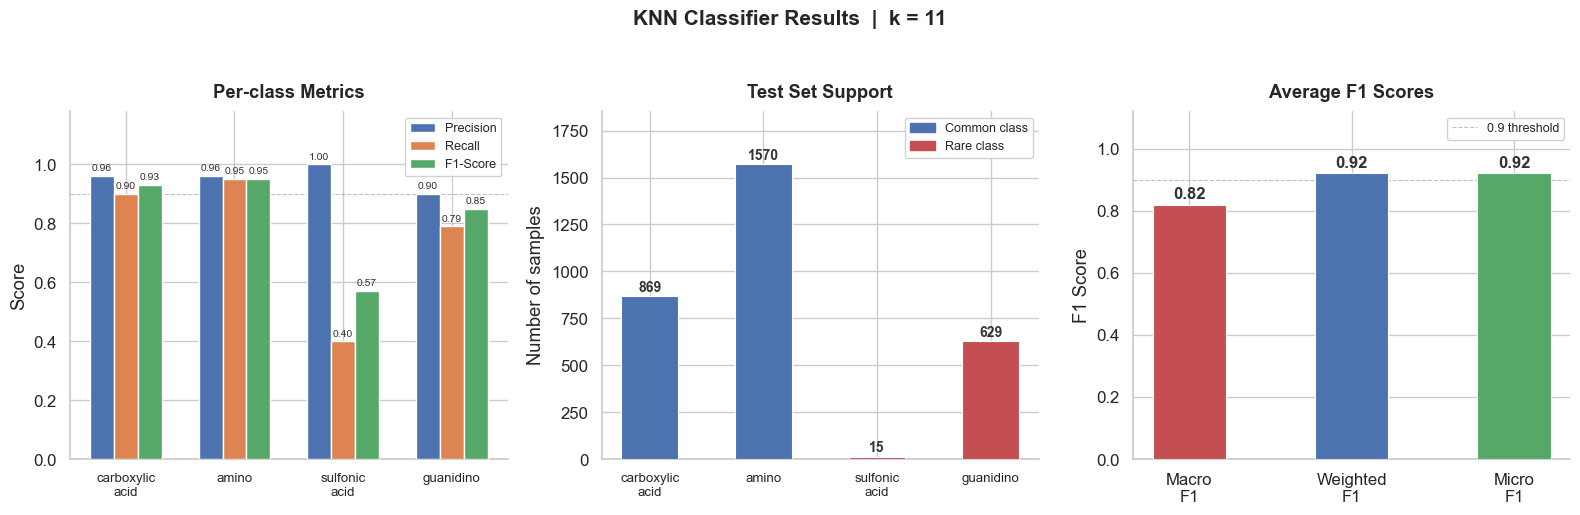

In [30]:
import matplotlib.patches as mpatches
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(style="whitegrid", font_scale=1.1)
PALETTE = {"Precision": "#4C72B0", "Recall": "#DD8452", "F1": "#55A868"}
COMMON_COLOR = "#4C72B0"
RARE_COLOR   = "#C44E52"

classes       = ['carboxylic\nacid', 'amino', 'sulfonic\nacid', 'guanidino']
classes_plain = ['carboxylic_acid', 'amino', 'sulfonic_acid', 'guanidino']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('KNN Classifier Results  |  k = 11', fontsize=15, fontweight='bold', y=1.03)

# ── Plot 1: Per-class metrics ──────────────────────────────────────────────
ax = axes[0]
precision = [0.96, 0.96, 1.00, 0.90]
recall    = [0.90, 0.95, 0.40, 0.79]
f1        = [0.93, 0.95, 0.57, 0.85]
x, w = np.arange(len(classes)), 0.22

b1 = ax.bar(x - w, precision, w, label='Precision', color=PALETTE["Precision"], zorder=3)
b2 = ax.bar(x,     recall,    w, label='Recall',    color=PALETTE["Recall"],    zorder=3)
b3 = ax.bar(x + w, f1,        w, label='F1-Score',  color=PALETTE["F1"],        zorder=3)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=7.5, color='#333333')

ax.set_xticks(x)
ax.set_xticklabels(classes, fontsize=9.5)
ax.set_ylim(0, 1.18)
ax.set_ylabel('Score')
ax.set_title('Per-class Metrics', fontweight='bold', pad=10)
ax.legend(framealpha=0.9, fontsize=9)
ax.axhline(0.9, color='gray', lw=0.8, ls='--', alpha=0.5, zorder=2)
sns.despine(ax=ax, left=False)

# ── Plot 2: Test set support ───────────────────────────────────────────────
ax = axes[1]
support = [869, 1570, 15, 629]
colors  = [COMMON_COLOR, COMMON_COLOR, RARE_COLOR, RARE_COLOR]
bars    = ax.bar(classes, support, color=colors, width=0.5, zorder=3,
                 edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, support):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            str(val), ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333333')

ax.set_title('Test Set Support', fontweight='bold', pad=10)
ax.set_ylabel('Number of samples')
ax.set_xticklabels(classes, fontsize=9.5)
ax.set_ylim(0, max(support) * 1.18)
common_patch = mpatches.Patch(color=COMMON_COLOR, label='Common class')
rare_patch   = mpatches.Patch(color=RARE_COLOR,   label='Rare class')
ax.legend(handles=[common_patch, rare_patch], framealpha=0.9, fontsize=9)
sns.despine(ax=ax, left=False)

# ── Plot 3: Macro / Weighted / Micro F1 ───────────────────────────────────
ax = axes[2]
avg_types  = ['Macro\nF1', 'Weighted\nF1', 'Micro\nF1']
values     = [0.82, 0.92, 0.92]
bar_colors = [RARE_COLOR, COMMON_COLOR, PALETTE["F1"]]
bars = ax.bar(avg_types, values, color=bar_colors, width=0.45, zorder=3,
              edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', va='bottom', fontsize=12,
            fontweight='bold', color='#333333')

ax.set_ylim(0, 1.12)
ax.set_title('Average F1 Scores', fontweight='bold', pad=10)
ax.set_ylabel('F1 Score')
ax.axhline(0.9, color='gray', lw=0.8, ls='--', alpha=0.5, zorder=2, label='0.9 threshold')
ax.legend(framealpha=0.9, fontsize=9)
sns.despine(ax=ax, left=False)

plt.tight_layout()
plt.savefig('knn_results.png', dpi=150, bbox_inches='tight')
plt.show()